#Automobile Price prediction

In [2]:
# ### 1. Imports
import numpy as np
import pandas as pd

# Explicitly enable the experimental IterativeImputer in scikit-learn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold

In [3]:
# ### 2. Data Loading & Feature Engineering
df = pd.read_csv("automobile_dataset.csv")

# Capture the missing state of 'Transmission' as a distinct binary feature
df['Transmission_missing'] = df['Transmission'].isna().astype(int)

# Isolate the target variable from the feature set
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

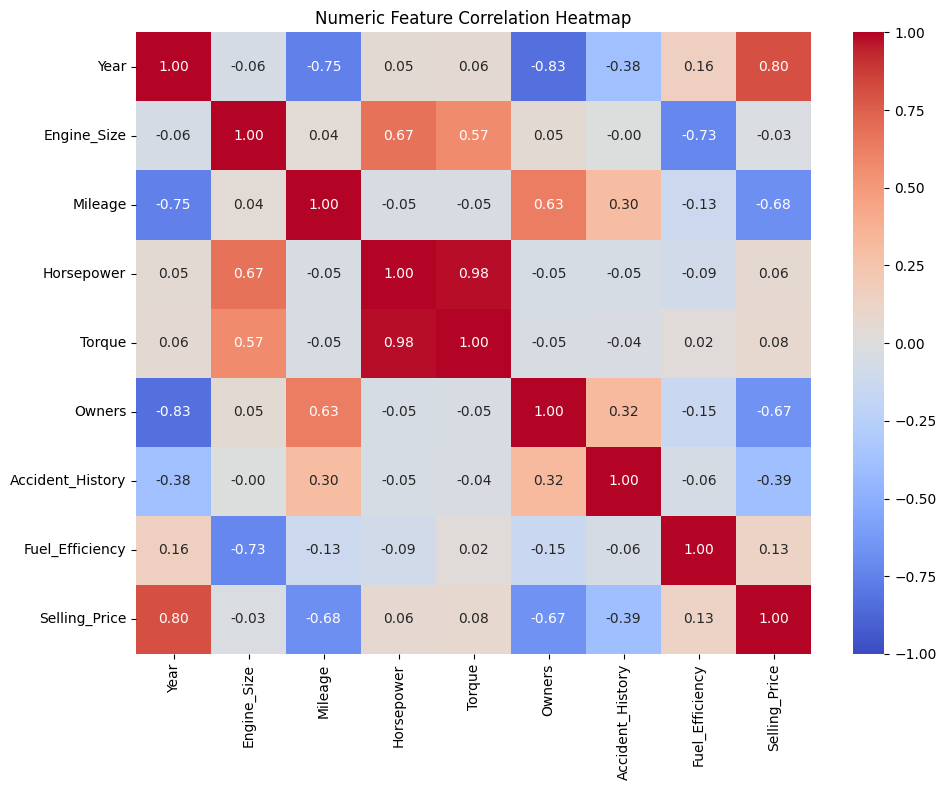

C:\Users\varsh\AppData\Local\Temp\ipykernel_15044\1307951107.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set2')


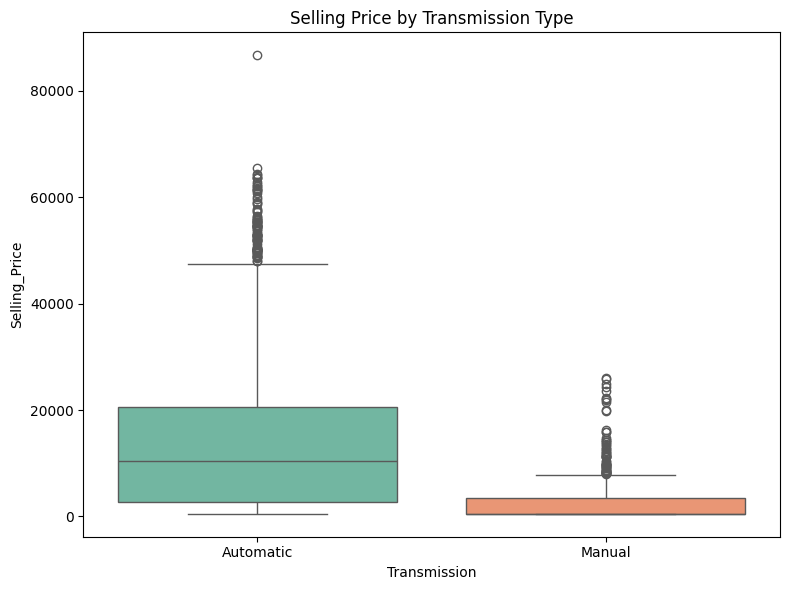

C:\Users\varsh\AppData\Local\Temp\ipykernel_15044\1307951107.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


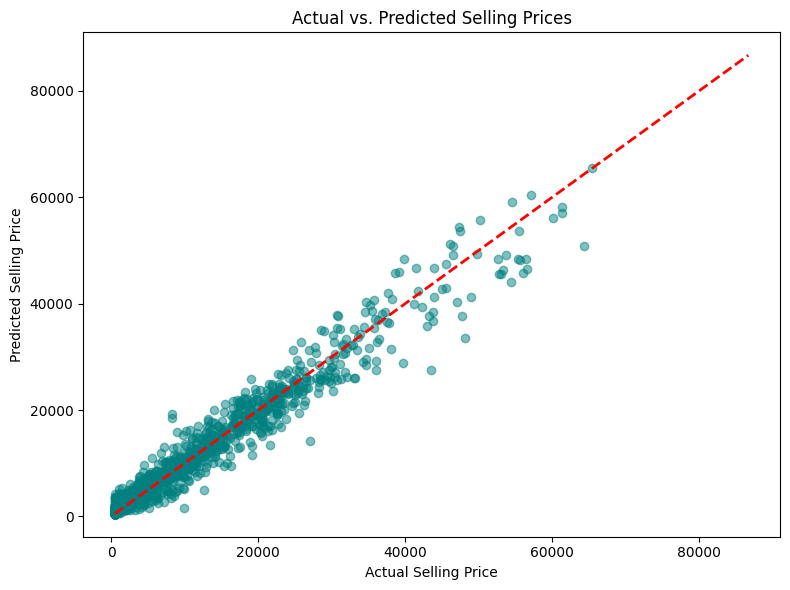

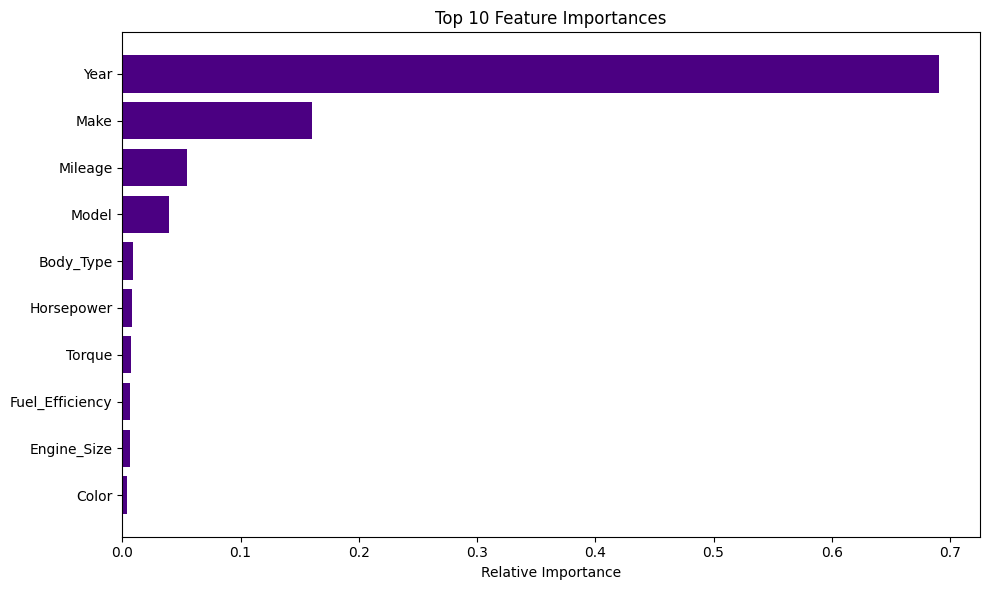

In [4]:
#Plots
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv("automobile_dataset.csv")

# ---------------------------------------------------------
# PLOT 1: Numeric Feature Correlation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# ---------------------------------------------------------
# PLOT 2: Selling Price by Transmission Type (Boxplot)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set2')
plt.title('Selling Price by Transmission Type')
plt.tight_layout()
plt.savefig("price_by_transmission.png")
plt.show()

# ---------------------------------------------------------
# PLOT 3 & 4 SETUP: Quick Pipeline for Prediction Visuals
# ---------------------------------------------------------
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=[np.number]).columns

# Basic preprocessor to feed the visualization model
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), 
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

# Fit a Random Forest model
model = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# PLOT 3: Actual vs. Predicted Selling Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # The perfect prediction line
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Selling Prices')
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

# PLOT 4: Top 10 Feature Importances

rf_model = model.named_steps['regressor']
all_features = num_cols.tolist() + cat_cols.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Isolate the top 10

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='indigo', align='center')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [5]:
# ### 3. Column Segmentation

# Segment columns
categorical_cols = ['Make', 'Model', 'Fuel_Type', 'Transmission', 'Service_History',
                    'Color', 'Body_Type', 'Drivetrain', 'Location']

# Group highly correlated numeric features 
regression_impute_cols = ['Engine_Size', 'Horsepower', 'Torque', 'Fuel_Efficiency']

# Group numeric features with weak or no correlation
simple_impute_num_cols = ['Accident_History']

In [6]:
# ### 4. Preprocessing Transformers

# Transformer A: Apply most-frequent strategy for categorical and weak-signal numeric columns
mode_impute = ColumnTransformer(
    transformers=[
        ('cat_mode', SimpleImputer(strategy='most_frequent'), categorical_cols),
        ('num_mode', SimpleImputer(strategy='most_frequent'), simple_impute_num_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

# Transformer B: Use OrdinalEncoder to convert text categories into numeric arrays
encode = ColumnTransformer(
    transformers=[
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         categorical_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

# Transformer C: Use BayesianRidge to mathematically predict missing values for correlated numeric features
regression_impute = ColumnTransformer(
    transformers=[
        ('reg_impute', IterativeImputer(estimator=BayesianRidge(), max_iter=25, random_state=42),
         regression_impute_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [7]:
# ### 5. Pipeline Construction & Target Transformation

# Wrap the Random Forest model in a TransformedTargetRegressor to apply and reverse a log1p transform
log_target_rf = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=100, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)

# Wrap all preprocessing layers and the model into a Scikit-Learn Pipeline to prevent data leakage
pipeline = Pipeline(steps=[
    ('mode_impute', mode_impute),
    ('encode', encode),
    ('regression_impute', regression_impute),
    ('scaler', StandardScaler()),
    ('model', log_target_rf)
])

In [8]:
# ### 6. Evaluation & Execution

# Use 5-Fold Cross-Validation for stable performance metrics
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

print("Executing pipeline cross-validation...")
results = cross_validate(
    pipeline,
    X, y,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

mae_scores = -results['test_mae']
rmse_scores = -results['test_rmse']
r2_scores = results['test_r2']

print("\nFinal Model Performance")
print(f"Average MAE:  ${mae_scores.mean():,.2f}")
print(f"Average RMSE: ${rmse_scores.mean():,.2f}")
print(f"Average R2:    {r2_scores.mean():.4f}")

Executing pipeline cross-validation...

Final Model Performance
Average MAE:  $1,933.45
Average RMSE: $3,239.98
Average R2:    0.9341
